In [128]:
import pandas as pd
import numpy as np
import pickle
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
import torch
from sklearn.preprocessing import LabelEncoder


In [129]:
warnings.filterwarnings('ignore')
print(f"XGBoost version: {xgb.__version__}")
print(f"CUDA avaiable: {torch.cuda.is_available}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    TREE_METHOD = 'hist'
    DEVICE = 'cuda'
else:
    TREE_METHOD = 'hist'
    DEVICE = 'cpu'
    
print(f"training on: {DEVICE}")

XGBoost version: 3.2.0
CUDA avaiable: <function is_available at 0x00000268555A0EB0>
GPU: NVIDIA GeForce RTX 5080
training on: cuda


In [138]:
train_df = pd.read_parquet("train_df.parquet")
test_df = pd.read_parquet("test_df.parquet")

with open('feature_list.pkl', 'rb') as f:
    feature_info = pickle.load(f)
    
ALL_FEATURES = feature_info['ALL_FEATURES']
TARGET = feature_info['TARGET']


X_train = train_df[ALL_FEATURES].copy()
y_train = train_df[TARGET].copy()
X_test = test_df[ALL_FEATURES].copy()
y_test = test_df[TARGET].copy()

cat_cols = [f for f in ALL_FEATURES if X_train[f].dtype.kind == 'O' 
            or pd.api.types.is_string_dtype(X_train[f])]
print(f"Categorical features: {len(cat_cols)}")
print(f"Categorical columns:  {cat_cols}")

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_test[col]]).astype(str).fillna('UNKNOWN')
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str).fillna('UNKNOWN')).astype(int)
    X_test[col]  = le.transform(X_test[col].astype(str).fillna('UNKNOWN')).astype(int)
    label_encoders[col] = le

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target: {TARGET}")
print(f"Feature: {len(ALL_FEATURES)}")
print(f"\nTest storms")
print(test_df['floodEvent'].value_counts())

Categorical features: 7
Categorical columns:  ['occupancyType', 'ratedFloodZone', 'floodZoneCurrent', 'causeOfDamage', 'storm_intensity_cat', 'prop_wind_exposure', 'state']
Train: (840853, 49), Test: (69222, 49)
Target: buildingDamageAmount_2024_capped
Feature: 49

Test storms
floodEvent
Hurricane Ian         38035
Hurricane Ivan        16059
Hurricane Florence    15128
Name: count, dtype: int64


In [131]:
print(X_train.dtypes.unique())
print(X_train['occupancyType'].dtype)
print(type(X_train['occupancyType'].iloc[0]))

[dtype('float64') dtype('int64')]
int64
<class 'numpy.int64'>


In [132]:
base = xgb.XGBRegressor(
    n_estimators = 1000,
    learning_rate = 0.05,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    tree_method = TREE_METHOD,
    device =DEVICE,
    random_state =  67,
    early_stopping_rounds = 50,
    eval_metric = 'rmse',
)

print("training XGBoost base model")
base.fit(
    X_train, y_train,
    eval_set = [(X_train, y_train),(X_test,y_test)],
    verbose = 50
)
print("baseline models complete")

training XGBoost base model
[0]	validation_0-rmse:104253.20163	validation_1-rmse:155020.92359
[50]	validation_0-rmse:71781.22426	validation_1-rmse:143656.87749
[100]	validation_0-rmse:67726.47586	validation_1-rmse:142531.01049
[150]	validation_0-rmse:65839.58417	validation_1-rmse:142332.63555
[159]	validation_0-rmse:65602.95446	validation_1-rmse:142140.90242
baseline models complete


In [133]:
y_pred = base.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae =  mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("── Baseline Model Performance ──────────────────")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE:  ${mae:,.0f}")
print(f"R²:   {r2:.4f}")

test_df['y_pred'] = y_pred
print("\n── Per-Storm Performance ───────────────────────")
for storm in test_df['floodEvent'].unique():
    mask = test_df['floodEvent'] == storm
    s_rmse = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
    s_mae = mean_absolute_error(y_test[mask], y_pred[mask])
    s_r2   = r2_score(y_test[mask], y_pred[mask])
    print(f"{storm:<25} RMSE: ${s_rmse:>10,.0f}  MAE: ${s_mae:>10,.0f}  R²: {s_r2:.4f}")

── Baseline Model Performance ──────────────────
RMSE: $142,008
MAE:  $68,070
R²:   0.1611

── Per-Storm Performance ───────────────────────
Hurricane Ian             RMSE: $   156,100  MAE: $    75,070  R²: 0.1275
Hurricane Ivan            RMSE: $   159,643  MAE: $    78,843  R²: 0.1652
Hurricane Florence        RMSE: $    62,915  MAE: $    39,035  R²: 0.2016


── Top 20 Features ─────────────────────────────
                           feature  importance
           hurdat2_min_pressure_mb    0.136283
             buildingPropertyValue    0.088101
            hurdat2_max_wind_speed    0.083113
                         longitude    0.071586
                   elevated_binary    0.044586
                  post_firm_binary    0.044376
           buildingReplacementCost    0.039295
                   obstructionType    0.036037
    totalBuildingInsuranceCoverage    0.034512
              building_age_at_loss    0.022363
             prop_dist_to_track_nm    0.021961
                     causeOfDamage    0.020323
                        yearOfLoss    0.020211
                     occupancyType    0.020024
                  prop_max_wind_kt    0.018233
                             state    0.017987
numberOfFloorsInTheInsuredBuilding    0.017424
                          latitude    0.016364
   basementEnclosureCrawlspaceType    0.015868
           

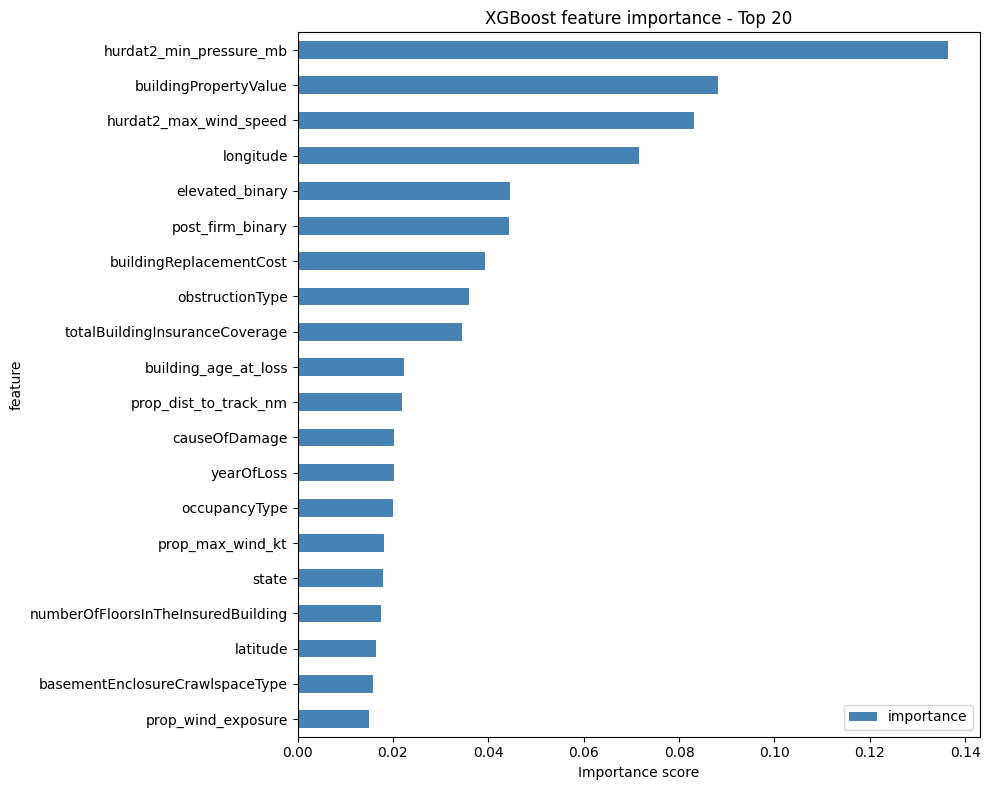

Feature importance saved ✅


In [134]:
importance_df = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': base.feature_importances_
}).sort_values('importance',ascending=False)

print("── Top 20 Features ─────────────────────────────")
print(importance_df.head(20).to_string(index=False))


fig, ax = plt.subplots(figsize= (10,8))
importance_df.head(20).sort_values("importance").plot.barh(
    x='feature', y='importance', ax=ax, color="steelblue"
)

ax.set_title("XGBoost feature importance - Top 20")
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig("feature importance.png", dpi=150)
plt.show() 
print("Feature importance saved ✅")

In [135]:
base.save_model('hurricane_severity_model.json')

print("Model saved to hurricane_severity_model.json ✅")
print(f"\nFinal metrics:")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  MAE:  ${mae:,.0f}")
print(f"  R²:   {r2:.4f}")

Model saved to hurricane_severity_model.json ✅

Final metrics:
  RMSE: $142,008
  MAE:  $68,070
  R²:   0.1611


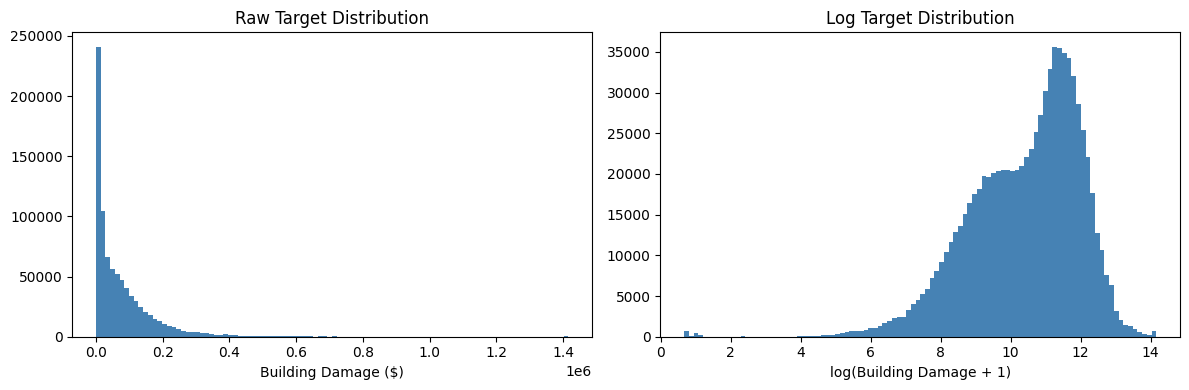

Skewness: 4.19
% of claims under $50k: 52.7%
% of claims under $100k: 72.7%


In [136]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Raw Target Distribution')
axes[0].set_xlabel('Building Damage ($)')
 
axes[1].hist(np.log1p(y_train), bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('Log Target Distribution')
axes[1].set_xlabel('log(Building Damage + 1)')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

print(f"Skewness: {y_train.skew():.2f}")
print(f"% of claims under $50k: {(y_train < 50000).mean()*100:.1f}%")
print(f"% of claims under $100k: {(y_train < 100000).mean()*100:.1f}%")

In [139]:
from sklearn.model_selection import train_test_split

X_train = train_df[ALL_FEATURES].copy()
y_train = train_df[TARGET].copy()
X_test  = test_df[ALL_FEATURES].copy()
y_test  = test_df[TARGET].copy()

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)
print(f"y_train shape: {y_train.shape}")
print(f"y_train_log shape: {y_train_log.shape}")
print(f"X_train shape: {X_train.shape}")

X_tr, X_val, y_tr_log, y_val_log = train_test_split(
    X_train, y_train_log,
    test_size=0.1,
    random_state=67
)

print(f"Log target skewness: {y_train_log.skew():.2f}")
print(f"Log target mean:     {y_train_log.mean():.2f}")
print(f"Log target std:      {y_train_log.std():.2f}")

base_log = xgb.XGBRegressor(
    n_estimators          = 3000,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 10,
    tree_method           = TREE_METHOD,
    device                = DEVICE,
    random_state          = 67,
    early_stopping_rounds = 50,
    eval_metric           = 'rmse',
)

print("\nTraining on log-transformed target...")
base_log.fit(
    X_tr, y_tr_log,
    eval_set=[(X_tr, y_tr_log), (X_val, y_val_log)],
    verbose=50
)

print(f"\nBest iteration: {base_log.best_iteration}")
print(f"Best score:     {base_log.best_score:.4f}")
print("Log model training complete ✅")

y_train shape: (840853,)
y_train_log shape: (840853,)
X_train shape: (840853, 49)
Log target skewness: -0.94
Log target mean:     10.40
Log target std:      1.58

Training on log-transformed target...


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:occupancyType: str, ratedFloodZone: str, floodZoneCurrent: str, causeOfDamage: str, storm_intensity_cat: str, prop_wind_exposure: str, state: str

In [ ]:
y_pred_log  = base_log.predict(X_test)
y_pred_dollars = np.expm1(y_pred_log)
y_test_dollars = np.expm1(y_test_log)

rmse = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
mae  = mean_absolute_error(y_test_dollars, y_pred_dollars)
r2   = r2_score(y_test_dollars, y_pred_dollars)

r2_log = r2_score(y_test_log, y_pred_log)

print("── Log Model Performance ──────────────────────")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE:  ${mae:,.0f}")
print(f"R² (dollar scale): {r2:.4f}")
print(f"R² (log scale):    {r2_log:.4f}")

print("\n── Per-Storm Performance ───────────────────────")
test_df['y_pred_log']     = y_pred_dollars
for storm in test_df['floodEvent'].unique():
    mask   = test_df['floodEvent'] == storm
    s_rmse = np.sqrt(mean_squared_error(y_test_dollars[mask], y_pred_dollars[mask]))
    s_mae  = mean_absolute_error(y_test_dollars[mask], y_pred_dollars[mask])
    s_r2   = r2_score(y_test_dollars[mask], y_pred_dollars[mask])
    s_r2_log = r2_score(y_test_log[mask], y_pred_log[mask])
    print(f"{storm:<25} RMSE: ${s_rmse:>10,.0f}  MAE: ${s_mae:>9,.0f}  R²: {s_r2:.4f}  R²(log): {s_r2_log:.4f}")

── Log Model Performance ──────────────────────
RMSE: $134,969
MAE:  $71,499
R² (dollar scale): -0.2192
R² (log scale):    -0.3608

── Per-Storm Performance ───────────────────────
Hurricane Ian             RMSE: $   181,011  MAE: $   89,374  R²: -0.1732  R²(log): 0.1567
Hurricane Sandy           RMSE: $   111,408  MAE: $   64,828  R²: -0.3472  R²(log): -1.0241
Hurricane Ivan            RMSE: $   180,897  MAE: $   85,430  R²: -0.0719  R²(log): 0.0987


In [ ]:
print("── Damage Distribution By Storm ────────────────")
for storm in ['Hurricane Katrina', 'Hurricane Harvey'] + list(test_df['floodEvent'].unique()):
    if storm in train_df['floodEvent'].values:
        data = y_train[train_df['floodEvent'] == storm]
    else:
        data = y_test[test_df['floodEvent'] == storm]
    print(f"{storm:<25} mean: ${data.mean():>10,.0f}  median: ${data.median():>10,.0f}  std: ${data.std():>10,.0f}")

print(f"\nOverall train mean: ${y_train.mean():,.0f}")
print(f"Overall test mean:  ${y_test.mean():,.0f}")

── Damage Distribution By Storm ────────────────
Hurricane Katrina         mean: $   152,512  median: $   130,730  std: $   135,473
Hurricane Harvey          mean: $   112,080  median: $    84,053  std: $   115,539
Hurricane Ian             mean: $   105,375  median: $    62,083  std: $   167,115
Hurricane Sandy           mean: $    76,373  median: $    51,030  std: $    95,985
Hurricane Ivan            mean: $   104,171  median: $    44,180  std: $   174,734

Overall train mean: $78,510
Overall test mean:  $84,548


In [ ]:
X_tr, X_val, y_tr_raw, y_val_raw = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=67
)

tuned_model = xgb.XGBRegressor(
    n_estimators          = 5000,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 10,
    tree_method           = TREE_METHOD,
    device                = DEVICE,
    random_state          = 67,
    early_stopping_rounds = 50,
    eval_metric           = 'rmse',
)

print("Training raw target model with validation split...")
tuned_model.fit(
    X_tr, y_tr_raw,
    eval_set=[(X_tr, y_tr_raw), (X_val, y_val_raw)],
    verbose=100
)

print(f"\nBest iteration: {tuned_model.best_iteration}")
print(f"Best score:     {tuned_model.best_score:.4f}")

Training raw target model with validation split...
[0]	validation_0-rmse:105399.58246	validation_1-rmse:105513.65949
[100]	validation_0-rmse:65916.26539	validation_1-rmse:67596.00373
[200]	validation_0-rmse:62668.06365	validation_1-rmse:65123.92495
[300]	validation_0-rmse:60773.58304	validation_1-rmse:63952.51398
[400]	validation_0-rmse:59346.79719	validation_1-rmse:63173.31081
[500]	validation_0-rmse:58247.55894	validation_1-rmse:62633.43019
[600]	validation_0-rmse:57330.58951	validation_1-rmse:62270.45174
[700]	validation_0-rmse:56393.74291	validation_1-rmse:61841.19338
[800]	validation_0-rmse:55563.68406	validation_1-rmse:61561.56530
[900]	validation_0-rmse:54875.33292	validation_1-rmse:61304.02563
[1000]	validation_0-rmse:54204.14543	validation_1-rmse:61137.32666
[1100]	validation_0-rmse:53564.05487	validation_1-rmse:60928.03160
[1200]	validation_0-rmse:52974.15366	validation_1-rmse:60749.40806
[1300]	validation_0-rmse:52467.50499	validation_1-rmse:60623.34668
[1400]	validation_0-r

In [ ]:
y_pred = tuned_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("── Final Model Performance ─────────────────────")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE:  ${mae:,.0f}")
print(f"R²:   {r2:.4f}")

print("\n── Per-Storm Performance ───────────────────────")
for storm in test_df['floodEvent'].unique():
    mask   = (test_df['floodEvent'] == storm).values
    s_rmse = np.sqrt(mean_squared_error(y_test.values[mask], y_pred[mask]))
    s_mae  = mean_absolute_error(y_test.values[mask], y_pred[mask])
    s_r2   = r2_score(y_test.values[mask], y_pred[mask])
    n      = mask.sum()
    print(f"{storm:<25} n={n:>6,}  RMSE: ${s_rmse:>10,.0f}  MAE: ${s_mae:>9,.0f}  R²: {s_r2:.4f}")

# Save
tuned_model.save_model('hurricane_severity_model_v2.json')
print("\nModel saved ✅")

── Final Model Performance ─────────────────────
RMSE: $118,268
MAE:  $62,191
R²:   0.0639

── Per-Storm Performance ───────────────────────
Hurricane Ian             n=38,035  RMSE: $   160,928  MAE: $   78,439  R²: 0.0727
Hurricane Sandy           n=135,455  RMSE: $    98,909  MAE: $   56,337  R²: -0.0619
Hurricane Ivan            n=16,059  RMSE: $   145,745  MAE: $   73,079  R²: 0.3042

Model saved ✅
